## Autora: Quezia Tedeschi

# Case Crédito Privado

# Sumário
- [Objetivo do case](#Objetivo-do-case)
- [Bases utilizadas](#Bases-utilizadas)
- [Desenvolvimento](#Bibliotecas)
- [Apresentação](#Análise-de-Fundos-de-Crédito-Privado)


## Objetivo do case
Analisar fundos com exposição a debêntures.

## Bases utilizadas
### Carteira
Link: https://dados.cvm.gov.br/dataset/fi-doc-cda
* Períodos selecionados: Jan/2025, Jul/2025, Jan/2026, Mar/2026

### Informe Diário
Link: https://dados.cvm.gov.br/dataset/fi-doc-inf_diario
* Período selecionado: Jan/2026 a Mar/2026

### Arquivo de Debêntures
Disponilibilizado

### Arquivo de cadastro Anbima
Disponibilizado



### Bibliotecas

In [2]:
import requests
import zipfile
import io
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import unicodedata


### Constantes e variáveis

In [3]:
nucleo = Path().resolve()
diretorio_dados = nucleo / "dados"

## URL base da carteira
url_carteira = "https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_{}.zip"
## períodos selecionados da carteira
periodo_carteira = [202501, 202506, 202601,202602]
# pasta dados carteira
pasta_carteira = diretorio_dados / "dados_carteira"
# prefixo carteira
prefixo_carteira = "cda_fi"

## URL base de informs diário
url_inf_diario = "https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_{}.zip"
## períodos selecionados do informe diário
periodo_inf_diario = [202601,202602,202603]
# pasta dados informe diário
pasta_inf_diario = diretorio_dados / "dados_inf_diario"
# prefixo informe diário
prefixo_inf_diario = "inf_diario_fi"

## Debêntures
arquivo_deb = "Debentures.com.br_Caracteristica_em_27-03-2026_as_08-48-24.xls"


## Anbima
arquivo_anbima = "ativos_anbima_202603271546.csv"


### Funções

In [4]:
def baixar_e_extrair(url_base, periodos, pasta_destino, prefixo_arquivo):
    """
    Objetivo:
    Baixar arquivos .zip a partir de uma URL parametrizada por período e extrair seu conteúdo
    diretamente na pasta destino, organizando por período.

    Parâmetros:
    url_base (str): URL com placeholder de período (ex: '.../cda_fi_{}.zip')
    periodos (list): Lista de períodos a serem baixados (ex: [202501, 202506])
    pasta_destino (str | Path): Caminho onde os arquivos serão armazenados
    prefixo_arquivo (str): Prefixo para nomear as subpastas por período

    Saída:
    Arquivos extraídos em subpastas no formato:
    {pasta_destino}/{prefixo}_{periodo}/

    Exemplo:
    baixar_e_extrair(
        url_base='https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_{}.zip',
        periodos=[202501, 202506],
        pasta_destino='dados/carteira',
        prefixo_arquivo='cda_fi'
    )

    Resultado esperado:
    dados/carteira/
        ├── cda_fi_202501/
        └── cda_fi_202506/
        
    """
    pasta_destino = Path(pasta_destino)
    pasta_destino.mkdir(parents=True, exist_ok=True)
    for periodo in periodos:
        url = url_base.format(periodo)
        pasta_periodo = pasta_destino / f"{prefixo_arquivo}_{periodo}"
        pasta_periodo.mkdir(parents=True, exist_ok=True)

        print(f"Baixando e extraindo: {url}")

        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 200:
                with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                    zip_ref.extractall(pasta_periodo)
                print(f"Pronto - extraído em: {pasta_periodo}")
            else:
                print(f"Erro {response.status_code} - {url}")

        except Exception as e:
            print(f"Erro: {url} -> {e}")

    print(f"Download e extração concluídos para {len(periodos)} períodos.")

def encontrar_concorrente(df_base_concorrentes, df_base_referencia, fundo_nome):
    """
    Objetivo:
    Identificar o fundo concorrente mais semelhante ao fundo de referência,
    com base na proximidade do SCORE_RISCO.

    Parâmetros:
    df_base_concorrentes (DataFrame): Base com fundos candidatos e coluna 'SCORE_RISCO'
    df_base_referencia (DataFrame): Base com fundos de referência (index = nome do fundo)
    fundo_nome (str): Nome do fundo de referência a ser comparado

    Saída:
    Série (linha do DataFrame) contendo o fundo concorrente mais próximo em termos de risco

    Exemplo:
    encontrar_concorrente(
        df_base_concorrentes=df_concorrentes,
        df_base_referencia=df_icatu,
        fundo_nome='Icatu Vanguarda Dinâmico'
    )

    Resultado esperado:
    Retorna o fundo concorrente com menor diferença de SCORE_RISCO
    em relação ao fundo de referência.
    """
    fundo_ref = (
        df_base_referencia
        .reset_index()
        .rename(columns={"index": "DENOM_SOCIAL"})
    )

    fundo_ref = fundo_ref[fundo_ref["DENOM_SOCIAL"] == fundo_nome].iloc[0]
    score_ref = fundo_ref["SCORE_RISCO"]

    df_temp = df_base_concorrentes.copy()
    df_temp["DISTANCIA_SCORE"] = (df_temp["SCORE_RISCO"] - score_ref).abs()

    concorrente = df_temp.sort_values("DISTANCIA_SCORE").iloc[0]

    return concorrente

def importar_arquivos_csv(arquivos):
    """
    Objetivo:
    Importar múltiplos arquivos CSV, adicionar a informação de período e consolidar
    todos em um único DataFrame.

    Parâmetros:
    arquivos (list[Path]): Lista de caminhos dos arquivos CSV a serem importados

    Saída:
    DataFrame consolidado contendo todos os arquivos, com a coluna adicional 'PERIODO'

    Exemplo:
    importar_arquivos_csv([
        Path('dados/carteira/cda_fi_202501/cda_fi_BLC_1_202501.csv'),
        Path('dados/carteira/cda_fi_202506/cda_fi_BLC_1_202506.csv')
    ])

    Resultado esperado:
    DataFrame único com os dados concatenados e coluna 'PERIODO'
    identificando a origem temporal de cada registro.
    """
    print(f"{len(arquivos)} arquivos encontrados")

    dfs = []
    for arquivo in arquivos:
    
        periodo = arquivo.stem.split("_")[-1]
    
        df = pd.read_csv( 
            arquivo,
            sep = ';',
            encoding = 'latin1',
            decimal = ',',
            low_memory = False)
        
        df["PERIODO"] = periodo
        
        dfs.append(df)
    
    df = pd.concat(dfs, ignore_index = True)
    return df


def classificar_indexador(valor):
    """
    Objetivo:
    Classificar o indexador de um ativo em categorias padronizadas
    (ex: CDI, IPCA, SELIC), com base no texto informado.

    Parâmetros:
    valor (str): Descrição do indexador (ex: 'IPCA + 5%', 'CDI', 'Prefixado')

    Saída:
    str: Categoria do indexador (IPCA, CDI, IGP, SELIC, PRE, OUTROS ou NÃO INFORMADO)

    Exemplo:
    classificar_indexador("IPCA + 6.5%")   -> "IPCA"
    classificar_indexador("CDI")           -> "CDI"
    classificar_indexador(None)            -> "NÃO INFORMADO"

    Resultado esperado:
    Padronização dos indexadores para facilitar análises agregadas
    e comparabilidade entre ativos.
    """    
    if pd.isna(valor):        
        return "NÃO INFORMADO"    
    
    valor = valor.upper().strip()

    if  "IPCA" in valor:
        return "IPCA"
    elif "CDI" in valor or "DI" in valor:
        return "CDI"
    elif "IGP" in valor:
        return "IGP"
    elif "SELIC" in valor:
        return "SELIC"
    elif "PRE" in valor or "PREFIX" in valor:
        return "PRE"
    else:
        return "OUTROS"

def classificar_setor(emissor):
    """
    Objetivo:
    Classificar o emissor em um setor econômico com base em palavras-chave
    presentes no nome, facilitando análises de concentração e diversificação.

    Parâmetros:
    emissor (str): Nome do emissor do ativo (ex: 'CPFL Energia', 'Sabesp')

    Saída:
    str: Setor classificado (Energia, Saneamento, Infraestrutura, etc.)

    Exemplo:
    classificar_setor("CPFL Energia")   -> "Energia"
    classificar_setor("Sabesp")         -> "Saneamento"
    classificar_setor("Empresa XYZ")    -> "Outros"

    Resultado esperado:
    Padronização dos emissores por setor, permitindo análises como
    concentração setorial e avaliação de risco da carteira.
    """
    emissor = str(emissor).upper()
    
    # Energia
    if any(x in emissor for x in ["ENERG", "ELETRO", "CPFL", "EDP", "ENGIE", "COELCE", "CEMIG", "NEOENERGIA"]):
        return "Energia"
    # Saneamento
    elif any(x in emissor for x in ["SANEAMENTO", "AGUA", "SABESP", "COPASA", "CAGECE", "CORSAN", "IGUA", "AEGEA"]):
        return "Saneamento"
    # Rodovias / Infraestrutura
    elif any(x in emissor for x in ["RODOVIA", "CONCESSIONARIA", "ECORODOVIAS", "AUTOPISTA", "ROTA", "COLINAS"]):
        return "Infraestrutura"
    # Telecom
    elif any(x in emissor for x in ["TELECOM", "FIBRA", "TELEFONICA", "TIM", "ALGAR", "BRISANET"]):
        return "Telecom"  
    # Logística / Transporte
    elif any(x in emissor for x in ["LOGISTICA", "TRANSPORT", "VLI", "MRS"]):
        return "Logística"  
    # Saúde
    elif any(x in emissor for x in ["SAUDE", "DOR", "HAPVIDA", "DIAGNOSTICOS"]):
        return "Saúde"    
    # Financeiro
    elif any(x in emissor for x in ["SECURITIZADORA", "VERT", "OPEA", "TRAVESSIA"]):
        return "Financeiro"   
    # Consumo / Varejo
    elif any(x in emissor for x in ["LOJAS", "RENNER", "SENDAS", "DROGASIL", "SMARTFIT"]):
        return "Consumo"   
    # Industrial / Materiais
    elif any(x in emissor for x in ["CIMENTO", "VOTORANTIM", "SUZANO", "BRASKEM"]):
        return "Industrial"   
    else:
        return "Outros"
    

In [16]:
## Download e Extração dos arquivos de Carteira e Informe Diário
baixar_e_extrair(
    url_base = url_carteira,
    periodos = periodo_carteira,
    pasta_destino = pasta_carteira,
    prefixo_arquivo = prefixo_carteira
)

baixar_e_extrair(
    url_base = url_inf_diario,
    periodos = periodo_inf_diario,
    pasta_destino = pasta_inf_diario,
    prefixo_arquivo = prefixo_inf_diario
)

Baixando e extraindo: https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_202501.zip
Pronto - extraído em: C:\Users\quezi\Case Icatu Asset\dados\dados_carteira\cda_fi_202501
Baixando e extraindo: https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_202506.zip
Pronto - extraído em: C:\Users\quezi\Case Icatu Asset\dados\dados_carteira\cda_fi_202506
Baixando e extraindo: https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_202601.zip
Pronto - extraído em: C:\Users\quezi\Case Icatu Asset\dados\dados_carteira\cda_fi_202601
Baixando e extraindo: https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_202602.zip
Pronto - extraído em: C:\Users\quezi\Case Icatu Asset\dados\dados_carteira\cda_fi_202602
Download e extração concluídos para 4 períodos.
Baixando e extraindo: https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202601.zip
Pronto - extraído em: C:\Users\quezi\Case Icatu Asset\dados\dados_inf_diario\inf_diario_fi_202601
Baixando e extraindo: https://dados.cvm.gov.

# Encontrar elenco de análise utilizando a base do CDA

Objetivo é encontrar 2 (dois) fundos da Icatu Vanguarda e depois dois respectivos concorrentes. Para isso, será utilizado os arquivos do CDA, cujo filtro são fundos que possuem debêntures associados. 

Conforme visto abaixo, os arquivos BLC_4 e BLC_6 possuem TP_ATIVO com debêntures. A partir desses dois arquivos importados, foi escolhido um conjunto de colunas que retratam desde a identificação do fundo até as características financeiras dele. Mais adiante, está disponível essas colunas de interesse da carteira segregadas pelo objetivo macro delas.

In [5]:
# Descobrindo qual dos arquivos do CDA contém as debêntures
for i in range(1, 9):
    arquivo = list(pasta_carteira.glob(f"cda_fi_*/cda_fi_BLC_{i}_*.csv"))
    
    if arquivo:
        df_temp = pd.read_csv(arquivo[0], sep=';', encoding='latin1', nrows=1000)
        print(f"\nBLC_{i}")
        print(df_temp["TP_ATIVO"].unique())


BLC_1
['Título público federal']

BLC_2
['Fundo de Investimento e de Cotas' 'FIDC' 'FI Imobiliário'
 'FI Participações' 'Fundos de Índice']

BLC_3
['SWAP']

BLC_4
['Debênture simples' 'Debênture Permutável' 'Bônus de subscrição'
 'Ação ordinária' 'BDR não patrocinado' 'BDR de ETF' 'Ação preferencial'
 'Debênture conversível' 'Certificado de depósito de ações'
 'Recibo de subscrição']

BLC_5
['Letra Financeira' 'CDB/ RDB' 'CDB Vinculado' 'DPGE']

BLC_6
['Debênture simples' 'Nota Promissória/ Commercial Paper/ Export Note'
 'CRA' 'Debênture conversível' 'CCB' 'NCA']

BLC_7
['Fundos Offshore' 'Ação ordinária' 'Bonds e Treasury' 'Outros'
 'Ação preferencial']

BLC_8
['Outros' 'Contrato Futuro' 'Ação ordinária'
 'Certificado de recebíveis imobiliários'
 'Outros Certificados de Recebíveis' 'Opção de compra' 'Opção de venda'
 'Futuro de DI1:DI de 1 dia' 'Futuro de DAP:Cupom de DI x IPCA'
 'Bônus de subscrição' 'Fundos de Índice' 'Recibo de subscrição'
 'Ação ou recibo de ação do Mercosul']


In [6]:
# Importação de todos os BLC_4 e BLC_6 baixados
arquivos_bcl_4 = list(pasta_carteira.glob("cda_fi_*/cda_fi_BLC_4_*.csv"))
arquivos_bcl_6 = list(pasta_carteira.glob("cda_fi_*/cda_fi_BLC_6_*.csv"))
arquivos = arquivos_bcl_4 + arquivos_bcl_6

df_cda = importar_arquivos_csv(arquivos = arquivos)

# Trazendo apenas as linhas referentes ao tipo de ativo Debênture
df_cda_deb = df_cda[df_cda["TP_ATIVO"].str.contains("Debênture", case = False, na = False)]

8 arquivos encontrados


## Seleção das colunas do CDA interessantes para o case
### Identificação do fundo
* CNPJ_FUNDO_CLASSE
* DENOM_SOCIAL
### Tempo
* DT_COMPTC
* PERIODO * inserido na etapa de importação
### Identificação do ativo
* CD_ATIVO
* DS_ATIVO
* CD_ISIN
* TITULO_CETIP
### Emissor
* PF_PJ_EMISSOR
* CPF_CNPJ_EMISSOR
* EMISSOR
### Posição do fundo
* QT_POS_FINAL
* VL_MERC_POS_FINAL
* VL_CUSTO_POS_FINAL
### Características financeiras
* DT_VENC
* CD_INDEXADOR_POSFX
* DS_INDEXADOR_POSFX
* PR_INDEXADOR_POSFX
* PR_CUPOM_POSFX
* PR_TAXA_PREFX

In [7]:
# Filtrando cda com as colunas de interesse
colunas_carteira = ["CNPJ_FUNDO_CLASSE",
    "DENOM_SOCIAL",
    "DT_COMPTC",
    "TP_ATIVO",
    "CD_ATIVO",
    "DS_ATIVO",
    "CD_ISIN",
    "EMISSOR",
    "CPF_CNPJ_EMISSOR",
    "QT_POS_FINAL",
    "VL_MERC_POS_FINAL",
    "VL_CUSTO_POS_FINAL",
    "DT_VENC",
    "DS_INDEXADOR_POSFX",
    "PR_INDEXADOR_POSFX",
    "PR_CUPOM_POSFX",
    "PR_TAXA_PREFX",
    "PERIODO"]

df_cda_final = df_cda_deb[colunas_carteira].copy()

# Identificando perfil do fundo 

Nesta etapa, para a identificação de dois perfis distintos, isto é, um fundo da Icatu Vanguarada mais conservador (maior diversificação da carteira e menor concentração por emissor) e outro mais arriscado (menor diversificação da carteira e maior concentração por emissor), foi construido um score simplificado de risco com base em três métricas calculadas a partir dos dados da carteira (CDA): concentração máxima por emissor, número de emissores e número de ativos. A primeira métrica, concentração máximo por emissor, recebeu o maior peso de 0,6, pois demonstra diretamente a relação de dependência entre fundo e emissor específico. Já as outras duas receberam peso no valor de 0,2 cada, pois estão atreladas a diversificação que reduz o score conforme a carteira se mostra mais pulverizada. Vale ressaltar, que foi optado pela normalização das variáveis permitindo a comparabilidade entre as métricas com escalas distintas, além de tornar o ranqueamento automático e aplicável para os concorrentes. 

Para evitar distorções na análise devido a baixa diversificação da carteira por limitação estrutural e não por estratégia, foi inserido um filtro utilizando as métricas número de emissor (acima de dois emissores) e número de ativos (acima de 50 ativos). 

Em uma análise prévia realizada mais adiante sobre a perfomance do fundo, utilizando a base do Informe Diário, constatou-se a a necessidade de retirada de dois fundos, um da Icatu Vanguarda e outro do conjunto de Concorrentes, pois não apresentavam dados ou dados inconsistentes. Os fundos mencionados são, respectivamente, ICATU VANGUARDA IPORÃ PG FIF CLASSE DE INVESTIMENTO MULTIMERCADO CRED PRIV - RESP LIMITADA e RIO DEBÊNTURES FUNDO INCENTIVADO DE INVESTIMENTO FINANCEIRO EM INFRAESTRUTURA RENDA FIXA.

Por fim, a seleção dos concorrentes é análoga ao ranqueamento produzido para a Icatu Vanguarda, com a adição da metodologia de comparação direta entre os fundos (Icatu Vanguarda e Concorrente) utilizando a proximidade dos scores como forma de identificação de perfis parecidos.

In [8]:
df_cda_base = df_cda_final.copy()

# Alterando o tipo da coluna para fins de cálculo
df_cda_base["VL_MERC_POS_FINAL"] = pd.to_numeric(
    df_cda_base["VL_MERC_POS_FINAL"],
    errors="coerce")

# Concentração por emissor: soma do valor de mercado dos ativos do emissor/patrimônio total da carteira
df_emissor = (df_cda_base.groupby(["DENOM_SOCIAL", "EMISSOR", "CNPJ_FUNDO_CLASSE"])["VL_MERC_POS_FINAL"].sum().reset_index())
## total por fundo
df_total = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["VL_MERC_POS_FINAL"].sum().reset_index(name="TOTAL_FUNDO"))
## % dentro do fundo
df_emissor = df_emissor.merge(df_total, on=["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])
df_emissor["PCT"] = df_emissor["VL_MERC_POS_FINAL"] / df_emissor["TOTAL_FUNDO"]
### portanto, maior concentração por emissor
df_concentracao = (df_emissor.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["PCT"].max())

# número de emissores
df_div = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["EMISSOR"].nunique())

# número de ativos
df_ativos = (df_cda_base.groupby(["DENOM_SOCIAL", "CNPJ_FUNDO_CLASSE"])["CD_ISIN"].nunique())

# Consolidando
df_resumo = pd.concat([df_concentracao, df_div, df_ativos], axis = 1)
df_resumo.columns = ["MAX_CONCENTRACAO", "QTD_EMISSORES", "QTD_ATIVOS"]

In [9]:
df_rank = df_resumo.copy()

# Filtro de diversificação
df_rank = df_rank[
    (df_rank["QTD_EMISSORES"] > 2) & 
    (df_rank["QTD_ATIVOS"] > 50) 
]

# normalização simples (escala comparável)
df_rank["CONC_NORM"] = df_rank["MAX_CONCENTRACAO"] / df_rank["MAX_CONCENTRACAO"].max()
df_rank["EMISSOR_NORM"] = df_rank["QTD_EMISSORES"] / df_rank["QTD_EMISSORES"].max()
df_rank["ATIVO_NORM"] = df_rank["QTD_ATIVOS"] / df_rank["QTD_ATIVOS"].max()

# score de risco (quanto maior, mais arriscado)
df_rank["SCORE_RISCO"] = (
    df_rank["CONC_NORM"] * 0.6   # peso maior (principal fator)
    + (1 - df_rank["EMISSOR_NORM"]) * 0.2
    + (1 - df_rank["ATIVO_NORM"]) * 0.2
)


# Concorrentes - retirada de qualquer Icatu
df_comp = df_rank.reset_index().rename(columns={"index": "DENOM_SOCIAL"}).copy()

df_comp = df_comp[
    ~df_comp["DENOM_SOCIAL"].str.contains("icatu", case=False, na=False)
].copy()

## Retirada de concorrentes não factíveis ao analisar o Informe Diário
df_comp = df_comp[~df_comp["CNPJ_FUNDO_CLASSE"].str.contains("54.909.880/0001-42", case = False, na = False)].copy()

# Opções de fundos da Icatu Vanguarda
df_cda_iv = df_rank.reset_index().rename(columns={"index": "DENOM_SOCIAL"}).copy()
df_cda_iv = df_cda_iv[df_cda_iv["DENOM_SOCIAL"].str.contains("icatu vanguarda", case = False, na = False)].copy()

## Retirada de Icatu Vanguarda não factível ao analisar o informe diário
df_cda_iv = df_cda_iv[~df_cda_iv["CNPJ_FUNDO_CLASSE"].str.contains("35.609.382/0001-30", case = False, na = False)].copy()

## Top 3 mais arriscados da Icatu Vanguarda
top_risco = df_cda_iv.sort_values("SCORE_RISCO", ascending=False).head(3)

## Top 3 mais conservadores
top_conservador = df_cda_iv.sort_values("SCORE_RISCO", ascending=True).head(3)

# Dois representantes da Icatu Vanguarda
fundo_conservador = top_conservador["DENOM_SOCIAL"].iloc[0]
fundo_arriscado = top_risco["DENOM_SOCIAL"].iloc[0]

## Respectivos concorrentes dos fundos representantes da Icatu Vanguarda
conc_conservador = encontrar_concorrente(df_comp, df_rank, fundo_conservador)
conc_arriscado = encontrar_concorrente(df_comp, df_rank, fundo_arriscado)


## Perfil mais arriscado
O fundo ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPRIV PREV - RESP LIMITADA apresenta a maior concentração por emissor da amostra, o que domina as demais métricas e o posiciona como o fundo mais arriscado em termos de exposição ao risco de crédito. E o seu concocorrente, por proximidade de score, é o ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF MULT CRÉD PRIV RESP LIMITADA.

In [10]:
cnpj_iv_risco = top_risco["CNPJ_FUNDO_CLASSE"].iloc[0]
cnpj_conc_risco = conc_arriscado["CNPJ_FUNDO_CLASSE"]

exibir_arriscado = pd.DataFrame((top_risco.iloc[0], conc_arriscado))
exibir_arriscado = exibir_arriscado.fillna("-").reset_index(drop=True)

#### Perfil mais arriscado - Icatu Vanguarda x Concorrente mais próximo

In [11]:
exibir_arriscado

,DENOM_SOCIAL,CNPJ_FUNDO_CLASSE,MAX_CONCENTRACAO,QTD_EMISSORES,QTD_ATIVOS,CONC_NORM,EMISSOR_NORM,ATIVO_NORM,SCORE_RISCO,DISTANCIA_SCORE
0,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,53.444.176/0001-07,0.018537,4,122,0.177485,0.064516,0.283721,0.436843,-
1,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,58.013.738/0001-73,0.014084,3,65,0.134843,0.048387,0.151163,0.440996,0.004152


## Perfil mais conservador
O fundo ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE INVESTIMENTO RF CRED PRIV PREVIDENCIÁRIO - RESP  LTDA apresenta o menor nível de concentração por emissor, aliado a uma carteira com elevado número de ativos, caracterizando perfil mais conservador em termos de risco de crédito. O fundo JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM INVEST EM DEB DE INFRA RF CRÉD PRIV - RESP LIMITADA é o seu concorrente por proximação de score de risco.

In [12]:
cnpj_iv_conservador = top_conservador["CNPJ_FUNDO_CLASSE"].iloc[0]
cnpj_conc_conservador = conc_conservador["CNPJ_FUNDO_CLASSE"]

exibir_conservador = pd.DataFrame((top_conservador.iloc[0], conc_conservador))
exibir_conservador = exibir_conservador.fillna("-").reset_index(drop=True)

#### Perfil mais conservador - Icatu Vanguarda x Concorrente mais próximo

In [13]:
exibir_conservador

,DENOM_SOCIAL,CNPJ_FUNDO_CLASSE,MAX_CONCENTRACAO,QTD_EMISSORES,QTD_ATIVOS,CONC_NORM,EMISSOR_NORM,ATIVO_NORM,SCORE_RISCO,DISTANCIA_SCORE
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,34.081.211/0001-18,0.009074,6,165,0.086876,0.096774,0.383721,0.356027,-
1,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,54.834.372/0001-42,0.013540,4,234,0.129638,0.064516,0.544186,0.356043,0.000016


In [14]:
# Portanto, os fundos escolhidos:
fundos_escolhidos = [cnpj_iv_risco, cnpj_conc_risco, cnpj_iv_conservador, cnpj_conc_conservador]

df_cda_4 = df_cda_final[df_cda_final["CNPJ_FUNDO_CLASSE"].isin(fundos_escolhidos)]

# Para integrar o nome do fundo a partor do cda na base do informe diário por meio do cnpj
df_cda_4_aux = df_cda_4[["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"]].copy()
df_cda_4_aux = df_cda_4_aux.drop_duplicates(subset=["CNPJ_FUNDO_CLASSE"])

# Importação os dados de informe diário
arquivos_inf_diario = list(pasta_inf_diario.glob("inf_diario_fi_*/inf_diario_fi_*.csv"))

df_inf_diario = importar_arquivos_csv(arquivos_inf_diario)

df_inf_diario_aux = df_inf_diario[df_inf_diario["CNPJ_FUNDO_CLASSE"].isin(fundos_escolhidos)]
colunas_inf_diario = ["CNPJ_FUNDO_CLASSE", "DT_COMPTC", "VL_TOTAL", "VL_QUOTA", "VL_PATRIM_LIQ", "PERIODO"] 

df_inf_diario_4 = df_inf_diario_aux[colunas_inf_diario].copy()

# Integraçã entre cda e informe diário
df_inf_diario_4 = df_inf_diario_4.merge(
    df_cda_4_aux[["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"]],
    how="left",
    on="CNPJ_FUNDO_CLASSE"
)

3 arquivos encontrados


# Performance dos fundos utilizando o Informe Diário

Nesta primeira etapa, foi realizada a análise de performance dos quatro fundos selecionados com base no Informe Diário da CVM, considerando o período de janeiro a março de 2026. O objetivo é comparar a evolução da cota, o retorno acumulado e o patrimônio líquido dos fundos, estabelecendo uma visão inicial de comportamento e porte antes da análise de composição de carteira.

In [15]:
# removendo registros invalidos e ordenando pelo cnpj do fundo e data de competência
df_inf = df_inf_diario_4.dropna(subset=["DT_COMPTC", "VL_TOTAL", "VL_PATRIM_LIQ"])
df_inf = df_inf_diario_4.sort_values(["CNPJ_FUNDO_CLASSE", "DT_COMPTC"]).reset_index(drop=True)

## alterando o tipo do dado
df_inf["VL_QUOTA"] = pd.to_numeric(
    df_inf["VL_QUOTA"],
    errors="coerce")

df_inf["VL_PATRIM_LIQ"] = pd.to_numeric(
    df_inf["VL_PATRIM_LIQ"],
    errors="coerce")

# Métricas para avaliar a performance
## Retorno diário - variação real
df_inf["RETORNO_DIARIO"] = (
    df_inf.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].pct_change()
)

## Normalizando a cota - para fins de comparação
df_inf["COTA_BASE_100"] = (
    df_inf.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"]
          .transform(lambda s: s / s.iloc[0] * 100)
)
## Retorno acumulado 
df_inf["RETORNO_ACUMULADO"] = df_inf["COTA_BASE_100"] / 100 - 1

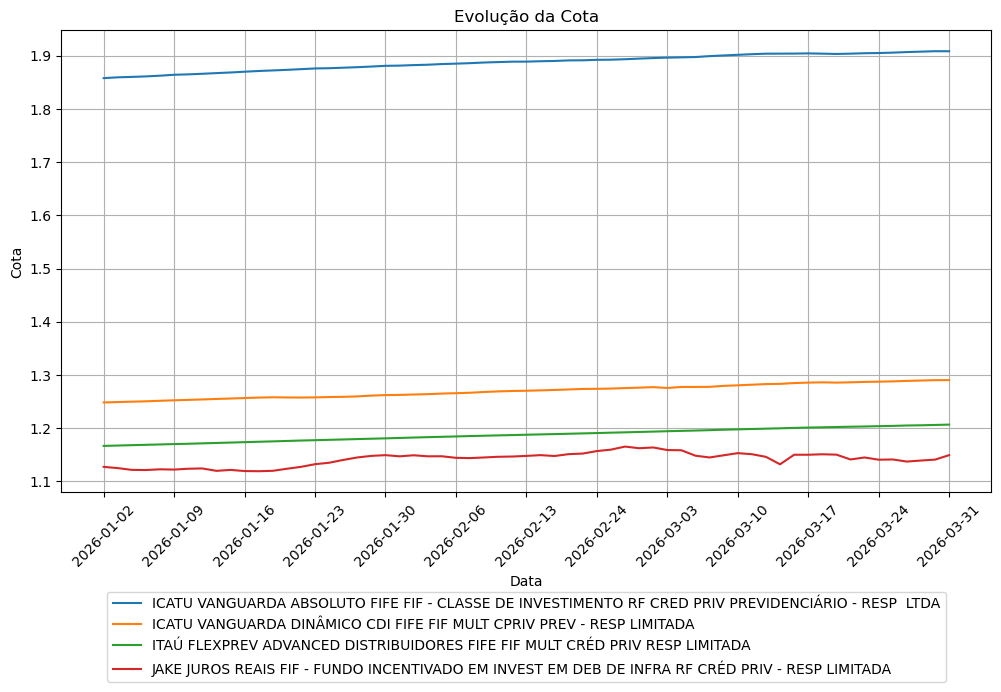

In [16]:
#Evolução da cota (não normalizada)
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["VL_QUOTA"], label=fundo)

plt.title("Evolução da Cota")
plt.xlabel("Data")
plt.ylabel("Cota")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
A evolução da cota apresenta baixa volatilidade, comportamento típico de fundos de crédito privado, onde o retorno tende a ser mais linear e menos sujeito a oscilações abruptas, diferentemente de ativos de renda variável.

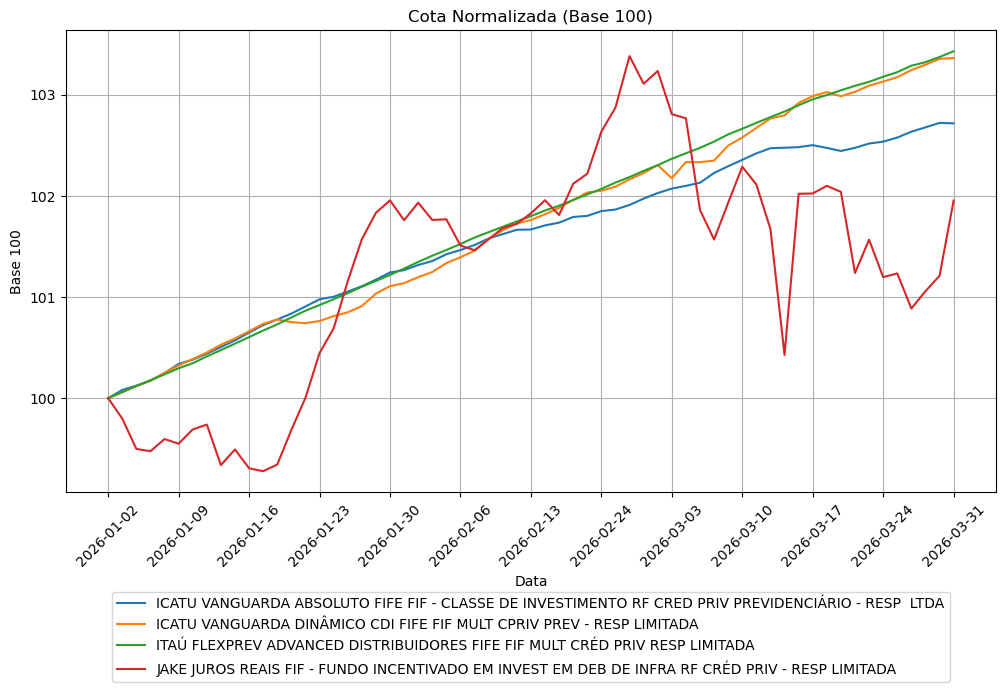

In [17]:
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["COTA_BASE_100"], label=fundo)

plt.title("Cota Normalizada (Base 100)")
plt.xlabel("Data")
plt.ylabel("Base 100")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
Normalizando o valor da cota, notamos maior oscilação ao longo do período para o fundo JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM INVEST EM DEB DE INFRA RD CRÉD PRIV - RESP LIMITADA, que foi classificado como fundo com perfil mais conservador. Esse resultado pode indicar, por exemplo, títulos sensíveis a juros, ou também concentração elevada, note que na tabela "Perfil mais conservador - Icatu Vanguarda x Concorrente mais próximo" o valor de concentração normalizado (CONC_NORM) é mais próximo dos fundos do perfil mais arriscado. O dois fundo classificados como fundo com perfil mais arriscado apresentam evolução estável e consistente, enquanto o fundo da Icatu Vaguarda mais conservador, um crescimento gradual.

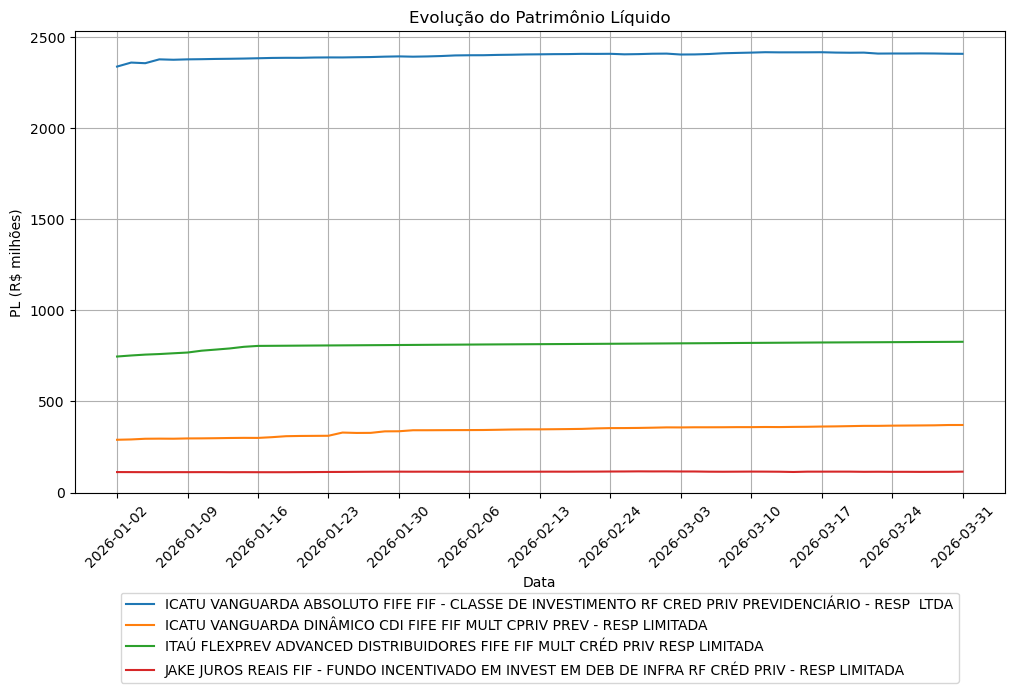

In [18]:
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["VL_PATRIM_LIQ"] / 1e6, label=fundo)

plt.title("Evolução do Patrimônio Líquido")
plt.xlabel("Data")
plt.ylabel("PL (R$ milhões)")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

#### Comentário:
Os quatro fundos apresentam crescimento consistente no período, indicando captação líquida positiva ou valorização dos ativos. 
Vale destacar uma análise conjunta entre o presente gráfico e o de cotas normalizadas. Esse cruzamento pode indicar um fundo robusto operacionalmente, diversificado e estável na geração do retorno. Para isso, é necessário volume de PL elevado e valor de cota consistente, o fundo de perfil conservador da Icatu Vaguarda atende a esses critérios.

In [19]:
# Resumo em tabela
df_resumo_4 = (
    df_inf.groupby(["CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL"])
          .agg(
              DATA_INICIO=("DT_COMPTC", "min"),
              DATA_FIM=("DT_COMPTC", "max"),
              COTA_INICIAL=("VL_QUOTA", "first"),
              COTA_FINAL=("VL_QUOTA", "last"),
              PL_INICIAL=("VL_PATRIM_LIQ", "first"),
              PL_FINAL=("VL_PATRIM_LIQ", "last"),
              PL_MEDIO=("VL_PATRIM_LIQ", "mean"),
              VOLATILIDADE_DIARIA=("RETORNO_DIARIO", "std")
          )
          .reset_index()
)

# Métricas derivadas
## retorno no período
df_resumo_4["RETORNO_PERIODO"] = (
    df_resumo_4["COTA_FINAL"] / df_resumo_4["COTA_INICIAL"] - 1
)

df_resumo_4["VARIACAO_PL_PERIODO"] = (
    df_resumo_4["PL_FINAL"] / df_resumo_4["PL_INICIAL"] - 1
)
df_resumo_4 = df_resumo_4.sort_values("RETORNO_PERIODO", ascending=False).reset_index(drop=True)

df_resumo_exibicao = df_resumo_4.copy()

for col in ["RETORNO_PERIODO", "VARIACAO_PL_PERIODO", "VOLATILIDADE_DIARIA"]:
    df_resumo_exibicao[col] = df_resumo_exibicao[col].apply(
        lambda x: f"{x:.2%}" if pd.notnull(x) else None
    )

df_resumo_exibicao["COTA_INICIAL"] = df_resumo_exibicao["COTA_INICIAL"].round(6)
df_resumo_exibicao["COTA_FINAL"] = df_resumo_exibicao["COTA_FINAL"].round(6)
df_resumo_exibicao["PL_MEDIO"] = df_resumo_exibicao["PL_MEDIO"].round(2)

#### Tabela resumo performance do fundo

In [20]:
df_resumo_exibicao

,CNPJ_FUNDO_CLASSE,DENOM_SOCIAL,DATA_INICIO,DATA_FIM,COTA_INICIAL,COTA_FINAL,PL_INICIAL,PL_FINAL,PL_MEDIO,VOLATILIDADE_DIARIA,RETORNO_PERIODO,VARIACAO_PL_PERIODO
0,58.013.738/0001-73,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,2026-01-02,2026-03-31,1.166803,1.206845,7.469290e+08,8.278696e+08,8.093886e+08,0.01%,3.43%,10.84%
1,53.444.176/0001-07,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,2026-01-02,2026-03-31,1.248482,1.290479,2.898571e+08,3.709794e+08,3.395722e+08,0.04%,3.36%,27.99%
2,34.081.211/0001-18,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,2026-01-02,2026-03-31,1.858070,1.908575,2.338983e+09,2.409048e+09,2.399173e+09,0.03%,2.72%,3.00%
3,54.834.372/0001-42,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,2026-01-02,2026-03-31,1.127394,1.149428,1.125408e+08,1.147403e+08,1.139756e+08,0.40%,1.95%,1.95%


#### Comentário:

Para concluir a análise de performance, apresenta-se um resumo das métricas com base no retorno do período, na volatilidade diária e na variação do patrimônio líquido, permitindo avaliar simultaneamente a rentabilidade, o risco e o crescimento dos fundos.

O fundo Itaú apresenta retorno elevado no período (3,32%) com volatilidade bastante reduzida (0,01%), indicando uma relação risco-retorno bastante eficiente. Além disso, observa-se crescimento relevante do patrimônio líquido (10,72%), sugerindo boa aceitação por parte dos investidores.

O Icatu Vanguarda Dinâmico apresenta retorno semelhante (3,30%), porém com maior volatilidade (0,04%), o que indica um nível de risco superior ao do Itaú. Em contrapartida, destaca-se pelo forte crescimento do patrimônio líquido (27,37%), indicando captação expressiva e maior dinamismo na estratégia do fundo.

Já o Icatu Vanguarda Absoluto apresenta retorno inferior (2,68%), com nível de volatilidade intermediário (0,03%) e crescimento mais moderado do patrimônio (3,07%). Esse comportamento sugere uma estratégia mais estável e conservadora dentro do universo analisado, com menor variabilidade e menor atratividade em termos de retorno no período.

Por fim, o fundo Jake Juros Reais apresenta o pior desempenho relativo, com retorno significativamente inferior (1,06%) e a maior volatilidade entre os fundos (0,39%), além de baixo crescimento do patrimônio (1,06%). Esse resultado indica uma relação risco-retorno desfavorável, caracterizada por maior exposição a risco sem a correspondente compensação em retorno.

# Composição da carteira

A análise da composição da carteira foi realizada a partir das posições em debêntures extraídas do CDA, enriquecidas com informações cadastrais dos ativos. Foram calculadas métricas de concentração por emissor, distribuição por indexador e prazo médio ponderado, permitindo avaliar o nível de diversificação e o perfil de risco dos fundos.

In [21]:
# Importar os dados do arquivo de Debêntures
df_deb = pd.read_csv(
    diretorio_dados / arquivo_deb,
    sep="\t",
    encoding="latin1",
    decimal=",",
    skiprows=4,
    header = 0)
df_deb.columns = df_deb.columns.str.strip()

## Colunas de interesse do arquivo de debêntures
colunas_deb_uteis = [
    "ISIN",
    "Codigo do Ativo",
    "Empresa",
    "Situacao",
    "Data de Emissao",
    "Data de Vencimento",
    "Garantia/Especie",
    "Classe",
    "indice",
    "Percentual Multiplicador/Rentabilidade",
    "CNPJ"]

df_deb_aux = df_deb[colunas_deb_uteis].copy()
df_deb_aux = df_deb_aux.rename(columns={
    "ISIN": "CD_ISIN",
    "Codigo do Ativo": "CODIGO_ATIVO",
    "Empresa": "EMISSOR_DEB",
    "Situacao": "SITUACAO",
    "Data de Emissao": "DATA_EMISSAO",
    "Data de Vencimento": "DATA_VENCIMENTO",
    "Garantia/Especie": "GARANTIA_ESPECIE",
    "Classe": "CLASSE",
    "indice": "INDEXADOR",
    "Percentual Multiplicador/Rentabilidade": "PERCENTUAL_RENTABILIDADE",
    "CNPJ": "CNPJ_EMISSOR"})

df_cda_deb_4 = df_cda_4.merge(df_deb_aux, how = "left", on = "CD_ISIN")

## alterando o tipo do dado
df_cda_deb_4["VL_MERC_POS_FINAL"] = pd.to_numeric(df_cda_deb_4["VL_MERC_POS_FINAL"], errors="coerce")

## O quanto o valor total investido em debêntures no fundo no mês representa dentro da carteira
df_cda_deb_4["VALOR_TOTAL"] = (df_cda_deb_4.groupby(["CNPJ_FUNDO_CLASSE", "PERIODO"])["VL_MERC_POS_FINAL"].transform("sum"))
df_cda_deb_4["PESO"] = (df_cda_deb_4["VL_MERC_POS_FINAL"] / df_cda_deb_4["VALOR_TOTAL"])

In [22]:
## COMPOSIÇÃO POR EMISSOR
df_cda_deb_4_emissor = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "EMISSOR_DEB"])["PESO"]
               .sum()
               .reset_index()
)

# Top emissores:
df_top_cda_deb_4_emissor = (
    df_cda_deb_4_emissor.sort_values(["DENOM_SOCIAL", "PERIODO", "PESO"], ascending=False)
              .groupby(["DENOM_SOCIAL", "PERIODO"])
              .head(5)
)

# Concentração em 5 maiores emissores
df_concentracao_cda_deb_4_emissor = (
    df_top_cda_deb_4_emissor.groupby(["DENOM_SOCIAL", "PERIODO"])["PESO"]
          .sum()
          .reset_index(name="TOP5_CONCENTRACAO")
)


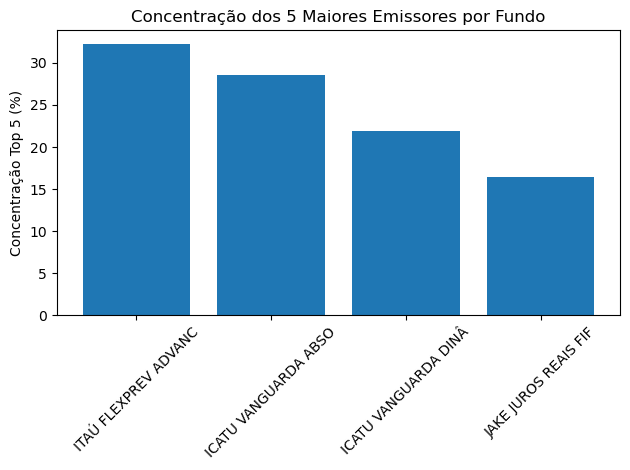

In [23]:
## Analisando para um período comum a todos
df_plot_concentracao_cda_deb_4_emissor = df_concentracao_cda_deb_4_emissor.copy()
df_plot_concentracao_cda_deb_4_emissor = df_plot_concentracao_cda_deb_4_emissor[df_plot_concentracao_cda_deb_4_emissor["PERIODO"] == "202506"]
df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"] = df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"] * 100
df_plot_concentracao_cda_deb_4_emissor = df_plot_concentracao_cda_deb_4_emissor.sort_values("TOP5_CONCENTRACAO", ascending=False)
df_plot_concentracao_cda_deb_4_emissor["NOME_CURTO"] = df_plot_concentracao_cda_deb_4_emissor["DENOM_SOCIAL"].str[:20]

plt.figure()
plt.bar(df_plot_concentracao_cda_deb_4_emissor["NOME_CURTO"], df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"])
plt.xticks(rotation = 45)
plt.ylabel("Concentração Top 5 (%)")
plt.title("Concentração dos 5 Maiores Emissores por Fundo")
plt.tight_layout()
plt.show()

#### Comentário:

O gráfico apresentado tem como objetivo avaliar o nível de concentração de risco nos cinco maiores emissores de cada fundo.
No grupo de fundos com perfil mais conservador, o Icatu Vanguarda Absoluto apresenta maior concentração em comparação ao seu concorrente (Jake Juros), indicando uma carteira mais exposta a poucos emissores. Já entre os fundos de perfil mais arriscado, observa-se que o fundo do Itaú possui maior concentração nos cinco principais emissores quando comparado ao Icatu Vanguarda Dinâmico. Além disso, ao comparar os fundos da própria Icatu, nota-se que o Icatu Vanguarda Dinâmico apresenta menor concentração em relação ao Icatu Vanguarda Absoluto, indicando uma carteira relativamente mais diversificada dentro do perfil mais arriscado comparado ao candidato mais conservador.

In [24]:
# Classificando setorialmente as debêntures
df_cda_deb_4["SETOR_EMISSOR_DEB"] = df_cda_deb_4["EMISSOR_DEB"].apply(classificar_setor)
df_setor = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "SETOR_EMISSOR_DEB"])["PESO"]
               .sum()
               .reset_index()
)

## Limitando a um período específico, comum a maioria e mais recente possível: 202506
df_setor_202506 = df_setor[df_setor["PERIODO"] == "202506"].copy()

## Agrupando setores com pouca exposição em Outros
df_setor_202506["SETOR_AJUSTADO"] = df_setor_202506["SETOR_EMISSOR_DEB"].where(
    df_setor_202506["PESO"] >= 0.05,
    "Outros")

df_setor_resumo = (
    df_setor_202506
    .groupby(["DENOM_SOCIAL", "PERIODO", "SETOR_AJUSTADO"])["PESO"]
    .sum()
    .reset_index())

df_setor_resumo_pivot = df_setor_resumo.pivot_table(
    index="DENOM_SOCIAL",
    columns="SETOR_AJUSTADO",
    values="PESO",
    fill_value=0
).reset_index()

#### Tabela de classificação setorial das debêntures

In [25]:
df_setor_resumo_pivot

SETOR_AJUSTADO,DENOM_SOCIAL,Energia,Infraestrutura,Logística,Outros,Saneamento,Saúde,Telecom
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,0.199117,0.054472,0.000000,0.493431,0.065533,0.130467,0.056979
1,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,0.190512,0.081124,0.053206,0.411905,0.122036,0.089606,0.051612
2,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,0.172016,0.000000,0.136137,0.630700,0.000000,0.061148,0.000000
3,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,0.273050,0.125731,0.000000,0.482492,0.059382,0.000000,0.059345


#### Comentário:

Para complementar a análise por emissor, foi construída uma classificação setorial dos emissores com base em regras heurísticas aplicadas aos nomes das empresas, permitindo analisar a exposição econômica das carteiras e identificar possíveis concentrações por setor.

Dessa forma, observou-se maior concentração na categoria “Outros”, que agrega setores com menor representatividade individual, mas que, em conjunto, se tornam relevantes. Ainda assim, é possível identificar o setor de "Energia" como o principal segmento de alocação entre os quatro fundos analisados.

Obervando os setores subsequentes, nota-se diferenciação entre os perfis de risco: nos fundos com perfil mais arriscado, destacam-se setores como "Saneamento" e "Logística", enquanto nos fundos de perfil mais conservador, maior presença em "Saúde" e "Infraestrutura". Essa distinção sugere diferentes estratégias de alocação e perfis de risco de crédito entre os fundos.

In [26]:
# Indexador: IPCA e CDI ou Não informado
df_cda_deb_4["INDEXADOR_CLASSE"] = df_cda_deb_4["DS_INDEXADOR_POSFX"].apply(classificar_indexador)
df_indexador_cda_deb_4 = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO", "INDEXADOR_CLASSE"])["PESO"]
               .sum()
               .reset_index()
)
df_indexador_cda_deb_4_pivot = df_indexador_cda_deb_4.pivot_table(
    index=["DENOM_SOCIAL", "PERIODO"],
    columns="INDEXADOR_CLASSE",
    values="PESO",
    fill_value=0
).reset_index()

## Seleção do período que contém valor para todos os 4 fundos
df_indexador_cda_deb_4_pivot_202506 = df_indexador_cda_deb_4_pivot[df_indexador_cda_deb_4_pivot["PERIODO"] == "202506"].copy()

#### Tabela de exposição por indexador tradicional

In [27]:
df_indexador_cda_deb_4_pivot_202506

INDEXADOR_CLASSE,DENOM_SOCIAL,PERIODO,CDI,IPCA,NÃO INFORMADO
1,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202506,0.137096,0.115106,0.747798
3,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202506,0.136366,0.049598,0.814036
5,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202506,0.167900,0.000000,0.832100
9,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202506,0.071041,0.056453,0.872506


#### Comentário:

Ao analisar por indexador, observou-se baixa representatividade de CDI e IPCA no período de junho de 2026, indicando que o retorno desses quatro fundos pode estar atrelado às característica de crédito do ativo e não pela variação direta de CDI ou inflação. Nesse sentido, será feito mais adiante uma análise envolvendo spread e prazo médio ponderado.

In [28]:
# Importar dados cadastrais Anbima
df_anbima = pd.read_csv(
    diretorio_dados / arquivo_anbima,
    sep=";",
    encoding="latin1",
    decimal=",")

## conversão para data, pois precisamos criar o período para relacionar com df_cda_deb_4
df_anbima["data"] = pd.to_datetime(df_anbima["data"])
df_anbima["PERIODO"] = df_anbima["data"].dt.year * 100 + df_anbima["data"].dt.month

## alterando o nome de campo ou o tipo do dado
df_anbima_mes= df_anbima.rename(columns={"codigo": "CD_ATIVO"})
df_anbima_mes["spread"] = pd.to_numeric(df_anbima_mes["spread"], errors="coerce")
df_anbima_mes["duration"] = pd.to_numeric(df_anbima_mes["duration"], errors="coerce")
df_anbima_mes["PERIODO"] = pd.to_numeric(df_anbima_mes["PERIODO"], errors="coerce")
df_anbima_mes["CD_ATIVO"] = df_anbima_mes["CD_ATIVO"].str.strip()

df_cda_deb_4["PERIODO"] = pd.to_numeric(df_cda_deb_4["PERIODO"], errors="coerce")


## União das bases
df_cda_deb_4 = df_cda_deb_4.merge(
    df_anbima_mes[["CD_ATIVO", "PERIODO", "spread", "duration"]],
    how="left",
    on=["CD_ATIVO", "PERIODO"])

### Verificando se temos dados suficientes para o cálculo de spread e duration: Sim
df_cda_deb_4["spread"].isna().mean(), df_cda_deb_4["duration"].isna().mean()


# Cálculos: spread médio e duration média
df_cda_deb_4["spread_pond"] = df_cda_deb_4["spread"] * df_cda_deb_4["PESO"]
df_spread = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])["spread_pond"]
    .sum()
    .reset_index(name="SPREAD_MEDIO"))
df_cda_deb_4["duration_pond"] = df_cda_deb_4["duration"] * df_cda_deb_4["PESO"]
df_duration = (
    df_cda_deb_4.groupby(["DENOM_SOCIAL", "PERIODO"])["duration_pond"]
    .sum()
    .reset_index(name="DURATION_MEDIA")
)

## Unindo as duas métricas
df_risco = df_spread.merge(df_duration, on=["DENOM_SOCIAL", "PERIODO"])

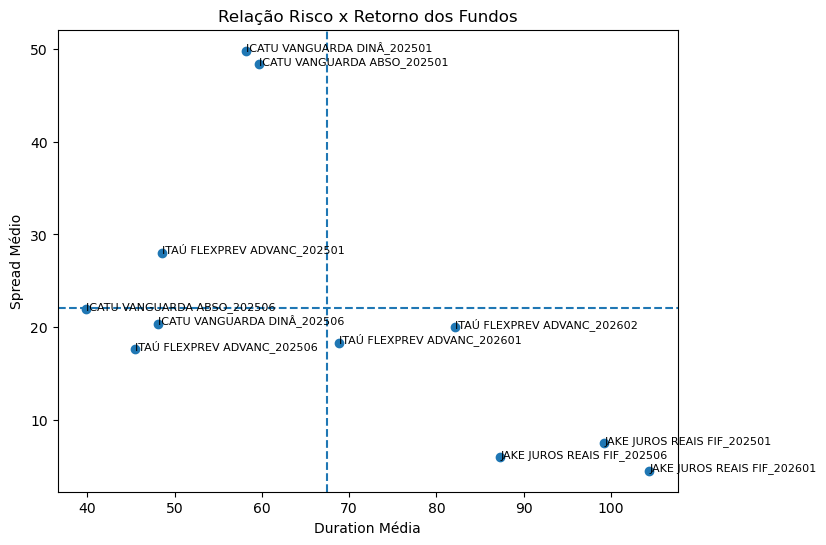

In [29]:
df_risco["NOME_CURTO"] = df_risco["DENOM_SOCIAL"].str[:20]  + "_" + df_risco["PERIODO"].astype(str)


plt.figure(figsize=(8,6))
plt.scatter(
    df_risco["DURATION_MEDIA"],
    df_risco["SPREAD_MEDIO"]
)

# nome dos fundos
for i, row in df_risco.iterrows():
    plt.text(
        row["DURATION_MEDIA"],
        row["SPREAD_MEDIO"],
        row["NOME_CURTO"],
        fontsize=8
    )
plt.axhline(df_risco["SPREAD_MEDIO"].mean(), linestyle='--')
plt.axvline(df_risco["DURATION_MEDIA"].mean(), linestyle='--')
plt.xlabel("Duration Média")
plt.ylabel("Spread Médio")
plt.title("Relação Risco x Retorno dos Fundos")

plt.show()

#### Comentário:

A estratégia adotada para a análise de risco e retorno consistiu na avaliação dos dois perfis definidos, bem como na observação da evolução das métricas ao longo do tempo para cada fundo. Para facilitar a visualização, foram consideradas as médias de spread e duration, permitindo a divisão do gráfico em quadrantes interpretativos.
Observa-se que, no período de janeiro de 2025, ambos os fundos da Icatu apresentavam a melhor relação risco-retorno, combinando níveis elevados de spread com duration moderada em comparação aos demais fundos analisados.
Ao longo de 2025, nota-se uma redução tanto do spread quanto da duration nesses fundos, indicando um possível reposicionamento para uma estratégia mais conservadora, com menor exposição a risco e, consequentemente, menor retorno esperado.
O fundo do Itaú segue dinâmica semelhante, iniciando com uma relação favorável entre retorno e risco. Contudo, ao longo do tempo, observa-se aumento da duration acompanhado de leve redução no spread, sugerindo uma mudança na composição da carteira com maior exposição a prazo, sem aumento proporcional de retorno.
Por fim, o fundo Jake Juros Reais apresenta a pior relação risco-retorno entre os analisados, mantendo consistentemente níveis elevados de duration associados a baixos spreads, o que indica maior exposição a risco sem a devida compensação em retorno.

#### Tabela de métricas de risco e retorno por fundo e período

In [30]:
df_risco.sort_values(["PERIODO", "DENOM_SOCIAL"])

,DENOM_SOCIAL,PERIODO,SPREAD_MEDIO,DURATION_MEDIA,NOME_CURTO
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202501,48.342028,59.689569,ICATU VANGUARDA ABSO_202501
2,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202501,49.804982,58.208056,ICATU VANGUARDA DINÂ_202501
4,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202501,28.052435,48.581305,ITAÚ FLEXPREV ADVANC_202501
8,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202501,7.505098,99.219535,JAKE JUROS REAIS FIF_202501
1,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,202506,21.917184,39.812753,ICATU VANGUARDA ABSO_202506
3,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,202506,20.354684,48.101881,ICATU VANGUARDA DINÂ_202506
5,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202506,17.640917,45.516949,ITAÚ FLEXPREV ADVANC_202506
9,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202506,5.986820,87.327632,JAKE JUROS REAIS FIF_202506
6,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,202601,18.340443,68.813189,ITAÚ FLEXPREV ADVANC_202601
10,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,202601,4.532833,104.393421,JAKE JUROS REAIS FIF_202601


# Análise de Fundos de Crédito Privado

## Objetivo

O objetivo desta análise é identificar qual fundo apresenta a melhor relação entre risco e retorno dentro de um conjunto de fundos com exposição a debêntures.

A análise foi estruturada em duas etapas:

- Avaliação da estrutura de risco da carteira  
- Análise do comportamento dos fundos ao longo do tempo

## Definição dos Perfis de Fundo

A seleção dos fundos foi realizada com base na composição das carteiras, utilizando métricas de risco estrutural:

- Concentração máxima por emissor  
- Quantidade de emissores  
- Quantidade de ativos  

A partir dessas métricas, foram definidos dois perfis:

- Perfil mais arriscado  
- Perfil mais conservador  

E seus respectivos concorrentes com estrutura semelhante.

## Comparação de Performance

Para comparar os fundos de forma justa, foi utilizada a cota normalizada, permitindo avaliar a evolução relativa ao longo do tempo.

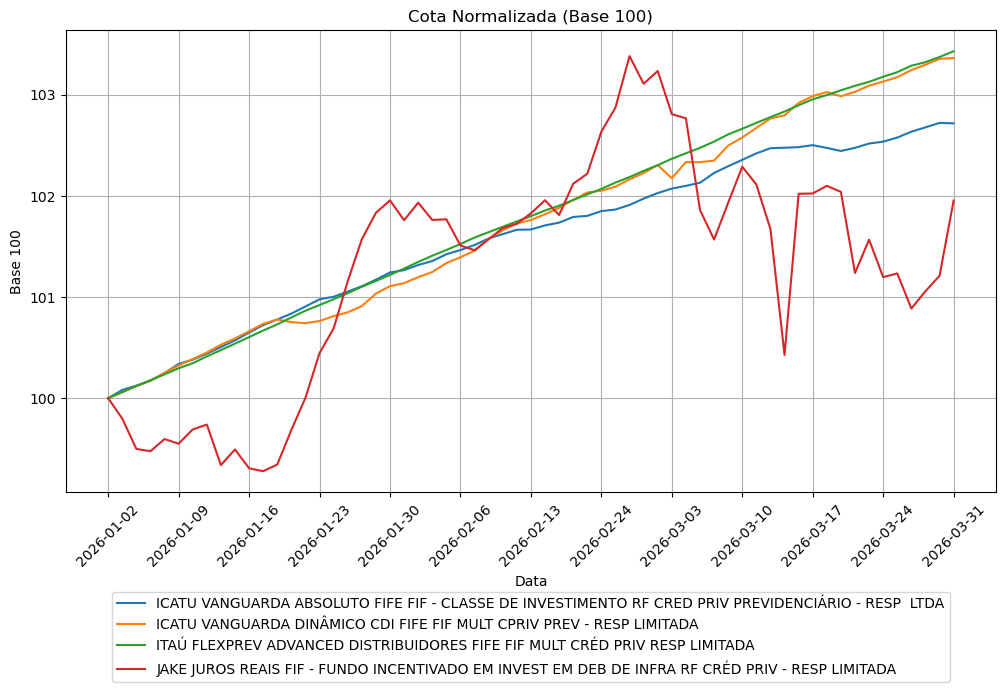

In [31]:
plt.figure(figsize=(12, 6))

for fundo, dados in df_inf.groupby("DENOM_SOCIAL"):
    plt.plot(dados["DT_COMPTC"], dados["COTA_BASE_100"], label=fundo)

plt.title("Cota Normalizada (Base 100)")
plt.xlabel("Data")
plt.ylabel("Base 100")
plt.legend(loc = "upper center", bbox_to_anchor= (0.5,-0.2), ncol=1)
plt.xticks(dados["DT_COMPTC"][::5], rotation = 45)
plt.grid(True)
plt.show()

**Principais Conclusões:**  
Itaú e Icatu Vanguarda Dinâmico apresentam os melhores desempenhos no período.  
No entanto, o Itaú se destaca por uma trajetória mais estável, indicando maior consistência na geração de retorno.

## Resumo de Performance

A análise consolidada considera retorno, volatilidade e crescimento do patrimônio líquido.

##### Tabela resumo performance do fundo

In [32]:
df_resumo_exibicao[["DENOM_SOCIAL", "VOLATILIDADE_DIARIA", "RETORNO_PERIODO", "VARIACAO_PL_PERIODO"]]

,DENOM_SOCIAL,VOLATILIDADE_DIARIA,RETORNO_PERIODO,VARIACAO_PL_PERIODO
0,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,0.01%,3.43%,10.84%
1,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,0.04%,3.36%,27.99%
2,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,0.03%,2.72%,3.00%
3,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,0.40%,1.95%,1.95%


**Principais Conclusões:**  
O Itaú apresenta a melhor combinação entre retorno elevado e baixa volatilidade, caracterizando a melhor relação risco-retorno da amostra.

## Estrutura da Carteira

A análise da composição da carteira permite entender onde o risco está concentrado.

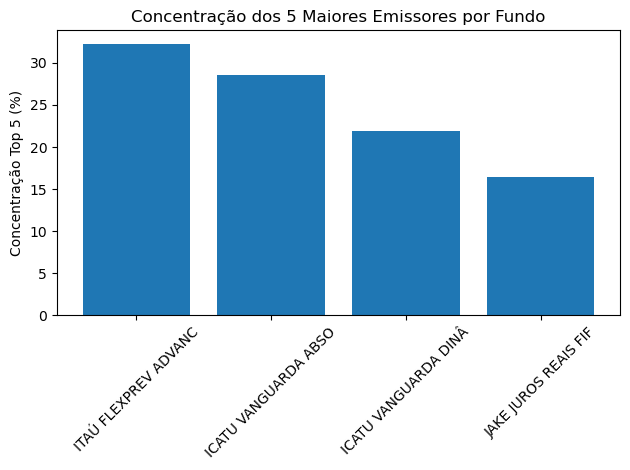

In [33]:
plt.figure()
plt.bar(df_plot_concentracao_cda_deb_4_emissor["NOME_CURTO"], df_plot_concentracao_cda_deb_4_emissor["TOP5_CONCENTRACAO"])
plt.xticks(rotation = 45)
plt.ylabel("Concentração Top 5 (%)")
plt.title("Concentração dos 5 Maiores Emissores por Fundo")
plt.tight_layout()
plt.show()

**Principais Conclusões:**  
Mesmo em fundos com múltiplos ativos, parte relevante do risco pode estar concentrada em poucos emissores, aumentando a exposição a eventos específicos de crédito.

## Exposição Setorial

A análise setorial complementa a leitura da concentração por emissor.

##### Tabela de classificação setorial das debêntures

In [34]:
df_setor_resumo_pivot

SETOR_AJUSTADO,DENOM_SOCIAL,Energia,Infraestrutura,Logística,Outros,Saneamento,Saúde,Telecom
0,ICATU VANGUARDA ABSOLUTO FIFE FIF - CLASSE DE ...,0.199117,0.054472,0.000000,0.493431,0.065533,0.130467,0.056979
1,ICATU VANGUARDA DINÂMICO CDI FIFE FIF MULT CPR...,0.190512,0.081124,0.053206,0.411905,0.122036,0.089606,0.051612
2,ITAÚ FLEXPREV ADVANCED DISTRIBUIDORES FIFE FIF...,0.172016,0.000000,0.136137,0.630700,0.000000,0.061148,0.000000
3,JAKE JUROS REAIS FIF - FUNDO INCENTIVADO EM IN...,0.273050,0.125731,0.000000,0.482492,0.059382,0.000000,0.059345


**Principais Conclusões:**  
A presença relevante de determinados setores, como energia, mostra que parte do risco está concentrada não apenas em emissores, mas também em segmentos econômicos específicos.

## Relação Risco x Retorno

A análise de spread e duration permite avaliar como o risco foi alocado ao longo do tempo.

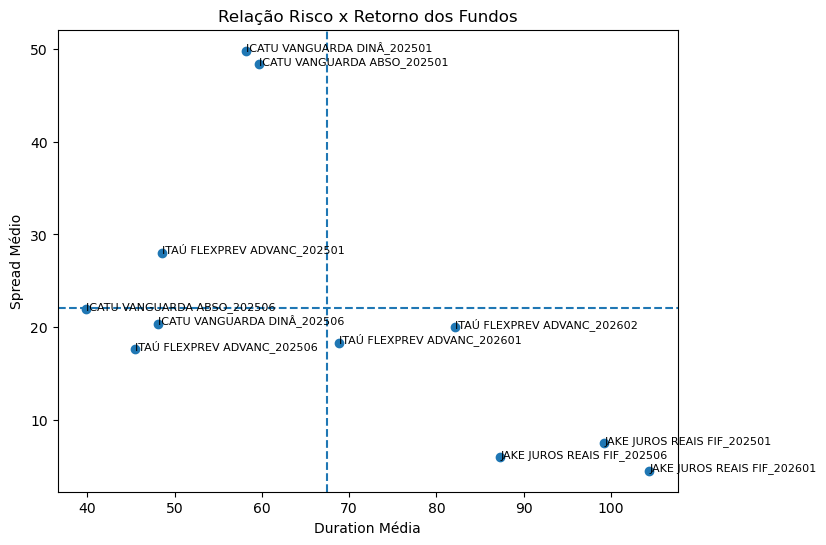

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_risco["DURATION_MEDIA"],
    df_risco["SPREAD_MEDIO"]
)

# nome dos fundos
for i, row in df_risco.iterrows():
    plt.text(
        row["DURATION_MEDIA"],
        row["SPREAD_MEDIO"],
        row["NOME_CURTO"],
        fontsize=8
    )
plt.axhline(df_risco["SPREAD_MEDIO"].mean(), linestyle='--')
plt.axvline(df_risco["DURATION_MEDIA"].mean(), linestyle='--')
plt.xlabel("Duration Média")
plt.ylabel("Spread Médio")
plt.title("Relação Risco x Retorno dos Fundos")

plt.show()

**Principais Conclusões:**  
Os fundos da Icatu iniciaram com maior exposição a risco e ao longo do tempo reduziram essa exposição.  
O Itaú, por sua vez, manteve uma alocação mais eficiente, resultando em melhor relação risco-retorno.

# Conclusão

A análise conjunta da estrutura da carteira e da performance dos fundos permite identificar diferenças claras na eficiência de cada estratégia.

### → Fundo mais interessante: Itaú Flexprev Advanced

Principais fatores:

- Maior retorno no período  
- Menor volatilidade  
- Trajetória mais estável  
- Melhor eficiência na alocação de risco  

### Destaque adicional

O Icatu Vanguarda Dinâmico apresentou forte performance e crescimento de patrimônio, sendo o principal destaque dentro da Icatu.